<a href="https://colab.research.google.com/github/lordoffatcats/TOL403G/blob/notebooks/T%C3%96L403G_Lokaverkefni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.2. Reiknirit
Útfærið reiknirit sem finnur stystu leið milli tveggja punkta með tilliti til vegalengdar, notið upplýsingar um vegalengd og hraða til að meta tímann. Einfaldasta leiðin til að leysa þetta er að nota reiknirit Dijkstra og fara síðan í aðrar útvíkkanir s.s. $A^\star$.

Þegar hlaða þarf bíl þarf að finna stystu leið í vegalengd sem tekur tillit til þess að á rafbílum er mögulega ekki hægt að fara alla leið á einni hleðslu. Þá þarf að módelera verkefnið sem stystu leið í mun stærra neti.

---
---

# 2.3.1. Innlestur á gögnum
Lesið inn netið úr skránum sem eru gefnar, `nodes.tsv` og edges.tsv. Í skránni `nodes.tsv` eru hnútar með auðkenni $(id)$, hnit $(x, y)$ og lengdar og breiddargráður. Í skránni `edges.tsv` eru leggi frá hnúti u til hnúts v með lengd length, mæld í metrum, nafn $(name)$ og hámarkshraða.

---

Hér eru gögnin `(.tsv skrárnar)` lesnar inn, og breytt í form sem hægt er að vinna með í python.

In [1]:
import pandas as pd
!git clone https://github.com/lordoffatcats/TOL403G.git

Cloning into 'TOL403G'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 46 (delta 19), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 880.38 KiB | 12.58 MiB/s, done.
Resolving deltas: 100% (19/19), done.


Inntakið er stefnt net af Íslandi, hver hnútur $v$ táknar mót tveggja vega og hefur auðkenni og staðsetningu, $(x, y)$ hnit og breiddar- og lengdargráður ($x, y$ hnitin eru betri upp á að teikna gögnin og reikna fjarlægð (í metrum) en lat/lon til að bera saman við úttak úr t.d. Google maps).

Leggirnir $(u, v)$ tákna vegi, þ.e. það er hægt að keyra á frá $u$ til $v$ og á milli þessara hnúta er ekki hægt að taka neinar aðrar ákvarðanir í umferðinni.

Skráin `nodes.tsv` inniheldur upplýsingar um hnútana, `edges.tsv` inniheldur upplýsingar
um vegina.

## 1. Innlestur gagna með Pandas

In [2]:
nodes = pd.read_table('TOL403G/nodes.tsv')
edges = pd.read_table('TOL403G/edges.tsv')
charging = pd.read_table('TOL403G/charging.tsv')

In [3]:
# Sanity check
display(nodes)
display(edges)
display(charging)

,id,x,y,lon,lat
0,0,347455.398,395070.736,-22.121370,64.024982
1,1,356654.934,399349.526,-21.937473,64.067271
2,2,349659.775,396020.416,-22.077281,64.034459
3,3,356636.442,399349.091,-21.937852,64.067260
4,4,356624.272,399325.852,-21.938078,64.067047
...,...,...,...,...,...
2761,2761,331946.284,380009.471,-22.421461,63.882871
2762,2762,331916.386,379952.497,-22.422006,63.882346
2763,2763,731016.264,513302.256,-14.090579,65.038817
2764,2764,731085.667,513289.028,-14.089132,65.038650


,u,v,length,name,highway,maxspeed_kph,oneway
0,0,2682,1948.768,Reykjanesbraut,trunk,90.0,1
1,1,3,18.992,Hlíðartorg,trunk,60.0,1
2,1,1658,653.666,Reykjanesbraut,trunk,60.0,1
3,2,1801,423.640,Reykjanesbraut,trunk,90.0,1
4,2,2678,208.144,NaN,trunk_link,50.0,1
...,...,...,...,...,...,...,...
4998,2763,558,2054.392,Norðfjarðarvegur,primary,90.0,0
4999,2763,2764,77.272,NaN,primary_link,NaN,1
5000,2765,558,60.781,Norðfjarðarvegur,primary,90.0,0
5001,2765,2483,3684.807,Austurvegur|Norðfjarðarvegur,primary,70.0,0


,station_index,osm_type,osm_id,nearest_node_id,lat,lon,max_kw,power_inferred,power_source,operator,name,tags_json
0,0,node,2944174209,1824,64.101077,-21.873190,22.0,1,connector_tier:socket:type2,Elko,NaN,"{""amenity"": ""charging_station"", ""capacity"": ""2..."
1,1,node,2962709565,291,64.140086,-21.888831,22.0,1,connector_tier:socket:type2,NaN,NaN,"{""amenity"": ""charging_station"", ""socket:type2""..."
2,2,node,3098691344,1088,64.100429,-21.884481,22.0,1,connector_tier:socket:type2,Orka náttúrunnar,ON,"{""access"": ""customers"", ""amenity"": ""charging_s..."
3,3,node,3760569527,570,66.025951,-16.495408,NaN,1,unknown,NaN,Camper Power Supply,"{""amenity"": ""charging_station"", ""name"": ""Campe..."
4,4,node,3760569528,570,66.025798,-16.494994,NaN,1,unknown,NaN,Camper Power Supply,"{""amenity"": ""charging_station"", ""name"": ""Campe..."
...,...,...,...,...,...,...,...,...,...,...,...,...
350,350,node,13236235029,431,64.372638,-21.566927,NaN,1,unknown,ON Power,NaN,"{""access"": ""yes"", ""amenity"": ""charging_station..."
351,351,node,13355815974,1421,64.154615,-21.950921,150.0,1,connector_tier:socket:type2_combo,N1,NaN,"{""amenity"": ""charging_station"", ""capacity"": ""6..."
352,352,node,13611302031,2307,65.773103,-23.167918,NaN,1,unknown,Orkubú Vestfjarða,NaN,"{""access"": ""yes"", ""amenity"": ""charging_station..."
353,353,node,13611302032,82,65.685683,-23.599479,NaN,1,unknown,Orkubú Vestfjarða,NaN,"{""amenity"": ""charging_station"", ""capacity"": ""2..."


## 2. Uppsetning á neti
Byrjum á að setja upp netið sem grannalista á forminu:

```yaml
hnútur1: [(granni1, þyngd), (granni2, þyngd), ...],
hnútur2: ...,
...
```

*(Við notum grannalista frekar en Grannafylki því að tímaflækja Dijkstra með fylki er $\mathcal{O}(|V|^2)$, en með lista fæst $\mathcal{O}(|E|\log |V|)$)*

In [4]:
net = {node_id: [] for node_id in nodes["id"]}

for u, v, w, oneway in zip(
    edges["u"], edges["v"], edges["length"]/edges["maxspeed_kph"], edges["oneway"]
):
    net[u].append((v, w))
    #if not oneway:
        #net[v].append((u, w))

# sanity check
for i in range(10):
    print(net[i])

[(2682, 21.652977777777778)]
[(3, 0.31653333333333333), (1658, 10.894433333333334)]
[(1801, 4.707111111111111), (2678, 4.16288)]
[(12, 0.14561666666666667)]
[(10, 0.24448333333333333)]
[(550, 4.045233333333333), (14, 0.4639333333333333)]
[(1947, 3.0650749999999998), (1946, 3.7262)]
[(1237, 32.18588888888889)]
[(2046, nan), (0, 5.370644444444444)]
[(1241, 2.8582555555555555), (7, 5.3611)]


# 2.3.2. Reiknirit Dijkstra
[A Note on Two Problems in Connexion with Graphs](https://ir.cwi.nl/pub/9256/9256D.pdf)

Útfærum reiknirit Dijkstra sem tekur inn tvo hnúta og finnur stystu leið milli tveggja hnúta.

Reiknirit Dijkstra er eftirfarandi:

1. Búum til mengi af öllum óheimsóttum hnútum.
2. Gefum hverjum hnút upphafsfjarlægð frá byrjunarhnút. $0$ fyrir upphafshnútinn og $\infty$ fyrir alla hina, þar sem við þekkjum ekki neina leið að þeim.
3. Veljum hnútinn úr óheimsótta menginu, sem hefur lægstu endanlegu fjarlægð. Í upphafi verður þetta upphafshnúturinn. Ef mengið er tómt eða allir hnútar hafa $\infty$ fjarlægð, þá stoppum við og förum í skref 6. Ef markmiðið er eingöngu leiðin að ákveðnum hnút $v$ stoppum við þegar valdi hnúturinn er $v$. Annars, þá höldum við áfram.
4. Fyrir valda hnútinn $u_i$, þá skoðum við alla óheimsótta nágranna hans og uppfærum fjarlægðir útfrá $u_i$. Þ.e. ef fjarlægðin að nágranna er styttri frá $u_i$, þá breytum við fjarlægðinni í þá lægri.
5. Eftir að allir óheimsóttir nágrannar $u_i$ eru uppfærðir, þá er $u_i$ fjarlægður úr óheimsótta menginu.
6. Þegar lykkjunni í skrefum 3-5 er lokið, þá innihalda allir heimsóttir hnútar stystu vegalengd frá byrjunarhnút.

Við útfærum mengið af óheimsóttum hnútum sem min-hrúgu með `heapq`, þar sem lyklarnir eru fjarlægðirnar og gildin eru hnútar.

In [7]:
from os import path
import heapq

def Dijkstra(G, start, end=None):
    """ Notar reiknirit Dijkstra til að finna stystu leið milli tveggja hnúta.
    Inntak:
        G: Net táknað sem grannalisti. Á forminu Dict[int, List[Tuple[int, float]]].
        start: id á upphafshnút í netinu
        end: id á endahnút í netinu.
    Úttak:
        fjalaegdir: Dict sem inniheldur fjarlægðir frá start að hnútum í netinu, þar til leið að end var fundin. Ef end=None er fjarlægð að öllum hnútum reiknuð.
        SPT: Dict sem heldur utan um Shortest Path Tree.

    """
    fjarlaegdir = {node: float("inf") for node in G}
    fjarlaegdir[start] = 0.0
    SPT = {node: None for node in G} # fyrir rakningu á leið milli start og end hnúta

    heap = [(0.0, start)]

    while heap:
        current_dist, u = heapq.heappop(heap)

        if u == end: # stoppum þegar valdi hnúturinn er endahnúturinn
            break

        if current_dist > fjarlaegdir[u]:
            continue

        for v, weight in G[u]:
            new_dist = current_dist + weight

            if new_dist < fjarlaegdir[v]:
                fjarlaegdir[v] = new_dist
                SPT[v] = u
                heapq.heappush(heap, (new_dist, v))
            #if end != None: # Stoppum þegar við erum komin á endahnút
                #if v == end:
                    #break
    return fjarlaegdir, SPT

def rekja_leid(SPT, start, end):
    """ Rekur stystu leið milli tveggja hnúta, gefið að reiknirit Dijkstra hafi verið notað á netið.
    Inntak:
        SPT: Dict sem heldur utan um Shortest Path Tree.
        start: id á upphafshnút
        end: id á endahnút
    Úttak:
        Listi af hnútum á milli start og end sem táknar stysta vega þar á milli.
    """
    leid = []
    v = end

    while v is not None:
        leid.append(v)
        v = SPT[v]
    leid.reverse()

    if leid and leid[0] == start:
        return leid
    return []

# 2.3.3. Framsetning
Sýnið leið milli 5 para af hnútum af ólíkri lengd, fyrir ca 5,10,50,100 og 400 km langar vegalengdir. Teiknið upp leiðirnar með því að nota hnitin á hnútunum. Tékkið ykkur af með því að bera saman leiðina sem er fundin og fjarlægðina miðað við kortavefi eins og t.d. Google Maps.

In [71]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # fallback
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
})


def plot_graph(nodes_df, edges_df, path=None, lon_min=-25, lat_min=63.2, lon_max=-13, lat_max=66.5):
    """ Teiknar mynd af neti og (mögulega) veg á skilgreindu svæði í kortahnitum.
    Inntak:
        nodes_df: Pandas dataframe sem inniheldur upplýsingar um hnúta í netinu.
        edges_df: Pandas dataframe sem inniheldur upplýsingar um leggi í netinu.
        path: Listi af hnútum (id-um) sem mynda vega sem skal teikna.
        lon_min: Neðri mörk x hnita sem skal teikna.
        lat_min: Neðri mörk y hnita sem skal teikna.
        lon_max: Efri mörk x hnita sem skal teikna.
        lat_max: Efri mörk y hnita sem skal teikna.
    Ísland er ca á longitude [-25, -13] og latitude [63-67]
    """
    # filtera hnúta og leggi fyrir staðsetningu
    #nodes_df = nodes_df[(nodes_df['lat'] >= lat_min) & (nodes_df['lat'] <= lat_max)]
    #nodes_df = nodes_df[(nodes_df['lon'] >= lon_min) & (nodes_df['lon'] <= lon_max)]
    #edges_df = edges_df[
    #    (edges_df['u']).isin(nodes_df['id'])
    #     & ((edges_df['v']).isin(nodes_df['id']))
    #]

    # lookup tafla frá id -> (lat, lon)
    node_pos = nodes_df.set_index('id')[['lon', 'lat']].to_dict('index')

    # teikna hnútana
    fig, ax = plt.subplots()
    ax.scatter(nodes_df['lon'], nodes_df['lat'], s=2)

    # teikna hleðslustöðvar
    for node_id in charging["nearest_node_id"]:
        x, y =[node_pos[node_id]['lon'], node_pos[node_id]['lat']]
        ax.scatter(x, y, marker="1", color="orange", s=20)

    # teikna leggina
    for _, row in edges_df.iterrows():
        u, v = row['u'], row['v']

        if u in node_pos and v in node_pos:
            x = [node_pos[u]['lon'], node_pos[v]['lon']]
            y = [node_pos[u]['lat'], node_pos[v]['lat']]
            ax.plot(x, y, color='grey', linewidth=0.5)

    # teikna veg
    if path:
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            if u in node_pos and v in node_pos:
                x = [node_pos[u]['lon'], node_pos[v]['lon']]
                y = [node_pos[u]['lat'], node_pos[v]['lat']]
                ax.plot(x, y, color='red', linewidth=2)


    ax.tick_params(labelsize=10)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.xaxis.set_major_formatter(
        mticker.FormatStrFormatter(r"$%.1f$")
    )
    ax.yaxis.set_major_formatter(
        mticker.FormatStrFormatter(r"$%.1f$")
    )
    ax.set_xlabel(r"$\mathrm{Longitude}$")
    ax.set_ylabel(r"$\mathrm{Latitude}$")
    plt.show

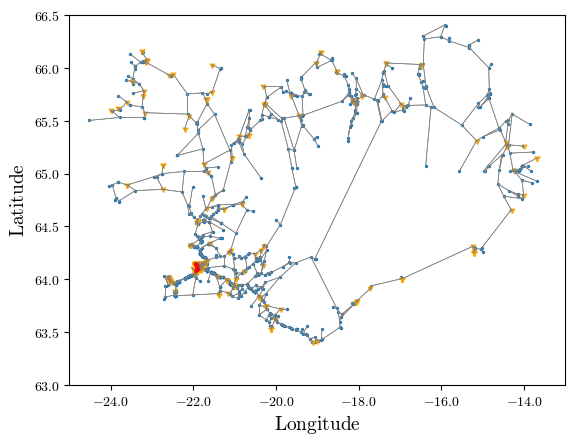

In [72]:
l = rekja_leid((Dijkstra(net,1660,1568)[1]), 1660, 1568)
plot_graph(nodes, edges, l, -25, 63, -13, 66.5)

# 2.3.4. Leiðarvísir
Takið stystu leið og búið til leiðarvísir, athugið að fjöldi hnúta verður mun meiri en fjöldi
það sem við myndum sýna notendum. ***(Hvað er átt við nákvæmlega með leiðarvísi?)***

# 2.3.5. Tímamælingar
Mælið tímann sem reikniritið dijkstra tekur að reikna fjarlægðir milli hnúta og hversu margir
hnútar eru skoðaðir fyrir þau fimm pör sem voru valin.

# 2.3.6.. $A^\star$ reikniritið
[A Formal Basis for the Heuristic Determination of Minimum Cost Paths](https://www.cs.auckland.ac.nz/courses/compsci709s2c/resources/Mike.d/astarNilsson.pdf)

Útfærið $A^\star$ reikniritið sem tekur inn lista af lokahnútum og reiknar fjarlægðir frá öllum hnútum í netinu. Sem neðra mat á fjarlægð á milli hnútanna má taka beina loftlínu milli punktanna. Mælið tíma og berið saman við reiknirit Dijkstra fyrir leiðir lengri en 50km, teiknið upp mynd af þeim hnútum sem voru skoðaðir.

In [39]:
import numpy as np

node_pos = nodes.set_index('id')[['lon', 'lat']].to_dict('index') # dict fyrir staðsetningu hnúta
node_posxy = nodes.set_index('id')[['x', 'y']].to_dict('index') # dict fyrir staðsetningu hnúta

def norm(u, v):
    """ Reiknar Kartesíska lengd milli tveggja hnúta.
    Inntak:
        u,v: hnútar sem reikna skal fjarlægð á milli.
    Úttak: Fjarlægð milli hnúta u og v.
    """
    u_x = node_posxy[u]['x']
    u_y = node_posxy[u]['y']
    v_x = node_posxy[v]['x']
    v_y = node_posxy[v]['y']
    return np.sqrt((u_x-v_x)**2 + (u_y-v_y)**2)

In [42]:
import heapq

def A_star(G, start, end=None, h=norm):
    """ Notar A* til að finna stystu leið milli tveggja hnúta.
    Inntak:
        G: Net táknað sem grannalisti. Á forminu Dict[int, List[Tuple[int, float]]].
        start: id á upphafshnút í netinu
        end: id á endahnút í netinu.
        h: Heuristískt nálgunarfall á raunfjarlægð milli tveggja hnúta.
    Úttak:
        fjalaegdir: Dict sem inniheldur fjarlægðir frá start að hnútum í netinu, þar til leið að end var fundin. Ef end=None er fjarlægð að öllum hnútum reiknuð.
        SPT: Dict sem heldur utan um Shortest Path Tree.
    """
    g_score = {node: float("inf") for node in G}
    g_score[start] = 0.0

    SPT = {node: None for node in G} # fyrir rakningu á leið milli start og end hnúta

    heap = []
    heapq.heappush(heap, (h(start, end), 0.0, start))

    while heap:
        f_u, g_u, u = heapq.heappop(heap)

        if u == end: # stoppum þegar valdi hnúturinn er endahnúturinn
            return g_score, SPT

        for v, weight in G[u]:
            nytt_g_v = g_u + weight

            if nytt_g_v < g_score[v]:
                SPT[v] = u
                g_score[v] = nytt_g_v
                heapq.heappush(heap, (nytt_g_v + h(end, v), nytt_g_v, v))
    return None # ef engin lausn finnst.

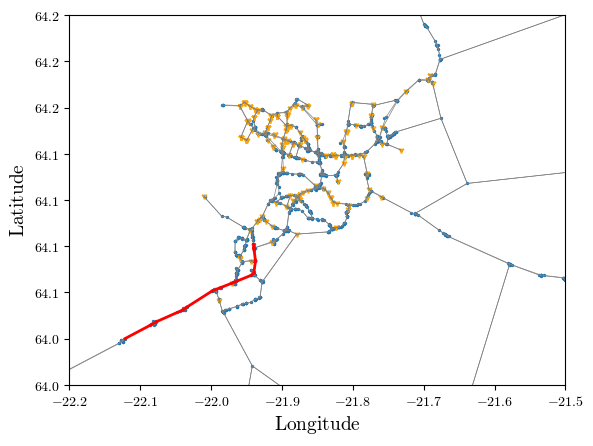

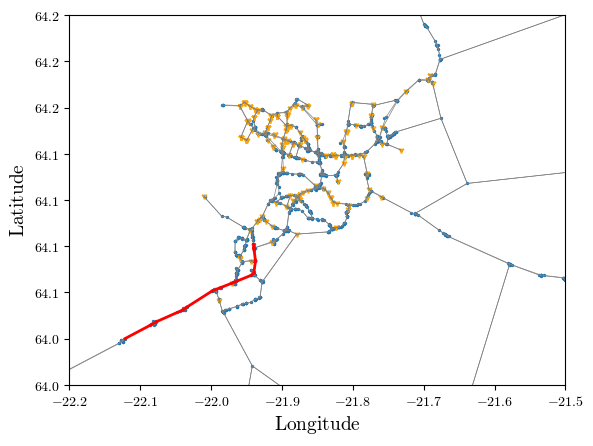

In [45]:
start = 0
end = 14
l1 = rekja_leid((Dijkstra(net,start,end)[1]), start, end)
l2 = rekja_leid((A_star(net,start,end)[1]), start, end)
plot_graph(nodes, edges, l1, -22.2, 64, -21.5, 64.2)
plot_graph(nodes, edges, l2, -22.2, 64, -21.5, 64.2)

# 2.3.7. Hleðslustöðvar

- Í skránni `charging.tsv` er listi yfir hleðslustöðvar. Í þessu verkefni á að vinna stystu
vegalengd fyrir lengri sem þarf mögulega að hlaða rafbílinn. ***(Veit ekki hvað í andskotanum þetta þýðir)***
- Reikniritið tekur inn upphafshleðslu og lámarkshleðslu á lokastað.
-  Finnið stystu vegalengd fyrir fullhlaðinn bíl sem keyrir frá Reykjavík til Akureyrar, annars vegar með 80Khw og 40Khw batteríi.
- Finnið gögn fyrir eyðslu per km og stækkið netið með því að halda utan um hleðsluna á hverri staðsetningu, þ.e. fyrir hvern hnút $v$ í upprunalega netinu þarf að búa til hnútana $(v,w)$ þar sem $w$ er hleðslan á bílnum, ***(Veit ekki hvað þetta þýðir)***
- ef við erum með legg $(u,v)$ í upprunalega netinu þá tengjum við saman hnútana $((u, w), (v, w −\Delta w))$ þar sem $\Delta w$ er orkan sem þarf til að keyra á milli hnútanna í upprunalega netinu.
- Á hleðsluhnútum er hægt að auka við orkuna, þ.e. tengja á milli $(v, w)$ og $(v, w′)$. Hversu marga nýja hnúta þarf að setja inn til að fá nothæfa lausn? ***(Hvað er ***$w'$***)***
---

Hér að neðan er útfærsla á reikniriti sem byggir ofan á $A^\star$. Ég er ekki viss um að það gefi alltaf bestu lausn, en mig grunar að það gefi "nógu góða" lausn, þ.e. að skekkjan frá bestu lausn sé frekar lítil.

Reikniritið verkar á stærra leitarrúm þar sem leið inniheldur ekki eingöngu hnúta, heldur einnig hleðslu á leiðinni. Þ.e. hnútarnir mengið er í raun tvívítt, þ.e. n-ta staða á leiðinni að lausn $u_n\in V\times W$ inniheldur upplýsingar um staðsetningu og hleðslu. Upprunalega voru notaðar fleytitölur fyrir hleðsluna, þ.e. $W\cong \mathbb{R}$, en þá verður stærðin á lausnarrúminu allt of stór. Því var kosið að diskrettera hleðsluna, þ.a. $W\cong \mathbb{N}$. Þá verður leitarrúmið *og lausnarrúmið* smærra sem leiðir til raunhæfri reiknitíma.

Í stað þess að geyma $g((u_n,w_n))$ fyrir hvert $(u_n,w_n)$, þá er aðeins geymt bestu stöðurnar m.t.t. hleðslu og raunvegalengdar ($g$). Þ.e. ef reikniritið lendir í hnút $u$ með hleðslu $w_x$, en við höfum fyrr í reikniritinu skráð sama hnút $u$, með hleðslu $w_y$ sem er betri, og vegalengdirnar eru þær sömu, hættum við leit í leið gegnum verri hleðsluna. Þetta smækkar leitarrúmið töluvert.

Til að höndla hleðsluhnúta (þ.e. `nearest_node_id`), er leggjum $(u,u)$ bætt við upprunalega netið. Þar sem okkur er sama um tímann sem það tekur að hlaða í þessum lið, þá gerum við bara ráð fyrir að bíllinn sé fullhlaðinn þegar svona hleðsluleggur valinn í leiðinni. Þar sem vegalengd við hleðslu eykst ekki, þá setjum við vigt þessara leggja í $0$. Þetta er auðvitað ad-hoc lausn á hleðslunni, en hún myndar undirstöðu sem við getum bætt ofan á til að besta tímann seinna meir.

Í ljós kom að óþarfa er að cast-a hleðslunni í heiltölur, og reikniritið var ennþá hraðvirkt.

In [56]:
import heapq

def RCSP_A(G, start, end, w_start, w_end, h):
    """ Reiknirit byggt á A* sem bestar stystu leið í neti með hleðslustöðvum, með skorðu um hleðslu á enda leiðar.
    Inntak:
        G: Net af hnútum og leggjum, þar sem leggur (u,v) hefur vigt. Hleðslustöðvar eru táknaðar sem leggir (u,u) með vigt 0.
        start: Id byrjunarhnúts.
        end: Id endahnúts.
        w_start: Upphafshleðsla á fullu batteríi.
        w_end: Skorða á hleðslu við enda leiðar.
        h: Heuristískt nálgunarfall á fjarlægð/kostnaði að lokahnút.
    Úttak:
        g_score: Tafla sem heldur utan um raunfjarlægðir í netinu.
        SPT: Shortest path tree sem inniheldur hnúta og hleðslu þeirra.
        (u, w_u): (lokahnútur, hleðsla í lokahnút).
        ---
        None, ef engin leið finnst.
    """
    SPT = {} # Shortest path tree með lykla (v, w_v) -> [u, w_u] þ.s. hnútur (u, w_u) er forveri (v,w_v)

    g_score = {} # tafla sem heldur utan um raunfjarlægðir á hnútum með hleðslu.
    g_score[(start, w_start)] = 0

    # u -> [(g_u1, w_u1)...(g_u_n, w_u_n)]
    best = {u: [] for u in G} # geymir lista af bestur (g_u, w_u) pörum fyrir hvern hnút

    heap = [] # biðröð sem geymir f(u_n), g(u_n), u, w_u.
    heapq.heappush(heap, (h(start,end), 0.0, start, w_start))

    while heap:
        f_u, g_u, u, w_u = heapq.heappop(heap)

        if u==end and w_u >= w_end: # ef við höfum fundið lausn þá skilum við lausninni.
            return g_score, SPT, (u, w_u)

        # Ef leið sem við erum á er verri í vegalengd og hleðslustöðu en leið í best,
        # þá hættum við að leita þar.
        verra = False
        for g, w in best[u]:
            if g_u >= g and w_u <= w:
                verra = True
                break
        if verra:
            continue

        nytt_best_u = []
        for g, w in best[u]:
            if not (g_u <= g and w_u >= w):
                # bætum bara viðgömlu bestu leiðum sem eru ekki verri í vegalengd og hleðslu.
                nytt_best_u.append((g,w))
        nytt_best_u.append((g_u, w_u))
        best[u] = nytt_best_u

        # Þetta er eiginlega bara standard A* nema með hleðslustöðvum
        for v,weight in G[u]:
            if u==v: # Ef hnútur er hleðslustöð.
                w_v = w_start # Fullhlöðum bílinn.
                nytt_g_v = g_u # Engin vegalengd bætist við þegar við hlöðum bílinn.
                stada = (u, w_v)
            else:
                w_v = w_u - weight #int(weight) # kastað í int til að minnka leitarrúmið.
                if w_v < 0: # Við megum ekki klára hleðslu á miðjum legg.
                    continue
                nytt_g_v = g_u + weight
                stada = (v, w_v)

            if stada not in g_score or nytt_g_v < g_score[stada]:
                g_score[stada] = nytt_g_v
                SPT[stada] = [u, w_u]
                f_v = nytt_g_v + h(v , end)
                heapq.heappush(heap, (f_v, nytt_g_v, v, w_v))
    return None # ef engin leið finnst.

In [58]:
def rekja_leid_charge(SPT, start, v, w_v):
    leid = []
    while True:
        leid.append(v)
        if (v, w_v) not in SPT:
            break #byrjunarstaða eða eih villa
        v, w_v = SPT[(v, w_v)]
        #print(f'{v}: {w_v}')
    leid.reverse()
    if leid and leid[0] == start:
        return leid
    return []

In [84]:
def nearest_node(lon, lat):
    closest_id = None
    min_dist = float('inf')
    for node_id, coords in node_pos.items():
        d = (lat - coords['lat'])**2 + (lon - coords['lon'])**2
        if d < min_dist:
            min_dist = d
            closest_id = node_id
    return closest_id

print(nearest_node(-20.55, 64.1))
print(net[329])

329
[(898, 4816.456), (1193, 12408.323), (1060, 6745.474)]


898: 103026.901, 43086.109, 93


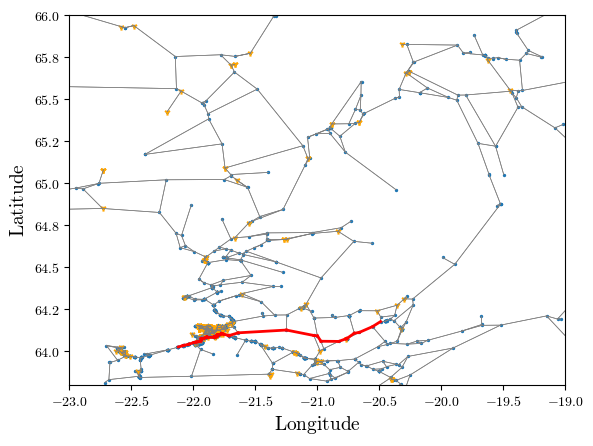

In [111]:
net = {node_id: [] for node_id in nodes["id"]}

for u, v, w, oneway in zip(
    edges["u"],
    edges["v"],
    edges["length"],
    edges["oneway"]
):
    net[u].append((v, w))

for u in charging["nearest_node_id"]:
    net[u].append((u, 0.0)) # bætum við hringrásarlegg með tíma/vigt 0 því okkur er sama um hleðslutímann nuna

start = 0
end = 898
result = RCSP_A(net,start,end, 61775, 0, norm)
if result is None:
    print("Engin leið")
else:
    g_score, SPT, (u, w_u) = result
    l1 = rekja_leid_charge(SPT, start, u, w_u)
    print(f'{u}: {g_score[(u, w_u)]}, {w_u}, {len(l1)}')
    plot_graph(nodes, edges, l1, -23, 63.8, -19, 66)

In [11]:
# sanity check
for i in range(10):
    print(net[i])

for v,w in net[2480]:
    print(f'{v}: {w}')
display(edges[edges['v']==2480])

[(2682, 1948.768)]
[(3, 18.992), (1658, 653.666)]
[(1801, 423.64), (2678, 208.144)]
[(12, 8.737)]
[(10, 14.669)]
[(550, 242.714), (14, 27.836)]
[(1947, 245.206), (1946, 186.31)]
[(1237, 2896.73)]
[(2046, 233.096), (0, 483.358)]
[(1241, 257.243), (7, 482.499)]
1693: 191.139
44: 190.639
2480: 0.0


,u,v,length,name,highway,maxspeed_kph,oneway
4593,2514,2480,818.128,Reykjanesbraut,trunk,80.0,1


## Skítamix kóði sem virkar ekki

In [40]:
"""
net_charge = {node_id: [] for node_id in nodes["id"]}

for u, v, w, oneway in zip(
    edges["u"], edges["v"], edges["length"], edges["oneway"]
):
    net_charge[u].append((v, w))

for u in charging["nearest_node_id"]:
    net_charge[u].append((u, 0.0)) # bætum við hringrásarlegg með tíma/vigt 0 því okkur er sama um hleðslutímann nuna

full_charge = 100000

def Dijkstra_charging(G, start, end=None, w_start=4e5, w_end=2e5, c=1.0):
    dist = {}
    dist[(start, w_start)] = 0.0
    SPT = {}

    heap = []
    heapq.heappush(heap, (0.0, start, w_start))

    while heap:
        current_dist, u = heapq.heappop(heap)
        curr_d_u, u, w_u = heapq.heappop(heap)

        if u == end and w_u >= w_end:
            break

        if curr_d_u > dist[(u, w_u)]:
            continue

        for v, weight in G[u]:
            if u == v:
                new_dist = curr_d_u
                w_v = int(full_charge)
            else:
                new_dist = curr_d_u + weight
                w_v = int(w_u - c*weight) # discrett til að minnka state-space-ið

            if (v, w_v) not in dist or new_dist < dist[(v, w_v)] and w_v >= 0:
                dist[(v, w_v)] = new_dist
                SPT[(v, w_v)] = [u, w_u]
                heapq.heappush(heap, (new_dist, v, w_v))
    return dist, SPT, w_v



def rekja_leid_charge(SPT, u, v, w_v):
    leid = []
    v = end

    while v is not None:
        leid.append(v)
        v, w_v = SPT[(v, w_v)]
    leid.reverse()

    if leid and leid[0] == start:
        return leid
    return []

start = 0
end = 200
dist, SPT, w_v = Dijkstra_charging(net_charge,start,end, 100000, 0)
#print(SPT)

l1 = rekja_leid_charge(SPT, start, end, w_v)
plot_graph(nodes, edges, l1, -23, 63.8, -19, 66)
"""

'\nnet_charge = {node_id: [] for node_id in nodes["id"]}\n\nfor u, v, w, oneway in zip(\n    edges["u"], edges["v"], edges["length"], edges["oneway"]\n):\n    net_charge[u].append((v, w))\n\nfor u in charging["nearest_node_id"]:\n    net_charge[u].append((u, 0.0)) # bætum við hringrásarlegg með tíma/vigt 0 því okkur er sama um hleðslutímann nuna\n\nfull_charge = 100000\n\ndef Dijkstra_charging(G, start, end=None, w_start=4e5, w_end=2e5, c=1.0):\n    dist = {}\n    dist[(start, w_start)] = 0.0\n    SPT = {}\n\n    heap = []\n    heapq.heappush(heap, (0.0, start, w_start))\n\n    while heap:\n        current_dist, u = heapq.heappop(heap)\n        curr_d_u, u, w_u = heapq.heappop(heap)\n\n        if u == end and w_u >= w_end:\n            break\n\n        if curr_d_u > dist[(u, w_u)]:\n            continue\n        \n        for v, weight in G[u]:\n            if u == v:\n                new_dist = curr_d_u\n                w_v = int(full_charge)\n            else:\n                new_di

# 2.3.8. Nákvæm lausn á hleðslu
Finnið stysta tíma með hleðslu en takið inn í myndina að hleðslustöðvarnar eru misgóðar og taka mislangan tíma að hlaða. Finnið stystu leið frá Reykjavík til Ísafjarðar. Búið ekki til allt stóra netið fyrirfram heldur haldið eingöngu utan um þá hnúta sem eru kannaðir með reikniritum Dijkstra eða $A^\star$.